## Rekurencyjne sieci neuronowe

In [13]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [6]:
symbol = 'AAPL'
data = yf.download(symbol, start='2010-01-01', end='2023-12-31')

prices = data[['Close']]
prices = prices.dropna()

print(prices.head())
plt.show()

[*********************100%***********************]  1 of 1 completed

Price          Close
Ticker          AAPL
2010-01-04  6.406480
2010-01-05  6.417557
2010-01-06  6.315475
2010-01-07  6.303802
2010-01-08  6.345710


In [11]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_prices = scaler.fit_transform(prices)

prices_scaled = pd.DataFrame(scaled_prices, index=prices.index, columns=prices.columns)

def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:i + sequence_length, 0])
        y.append(data[i + sequence_length, 0])
    return np.array(X), np.array(y)

sequence_length = 50
X, y = create_sequences(scaled_prices, sequence_length)
X = X.reshape((X.shape[0], X.shape[1], 1))

train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]


In [14]:
model = Sequential([
    LSTM(50, return_sequences=False, input_shape=(sequence_length, 1)),Dense(1)
])

model.compile(optimizer='adam', loss='mse')
print(model.summary())

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

None


In [15]:
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0021 - val_loss: 0.0012
Epoch 2/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.1138e-04 - val_loss: 8.7365e-04
Epoch 3/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 9.6646e-05 - val_loss: 8.6342e-04
Epoch 4/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 9.8004e-05 - val_loss: 0.0017
Epoch 5/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 8.6450e-05 - val_loss: 6.8977e-04
Epoch 6/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 8.4034e-05 - val_loss: 7.8706e-04
Epoch 7/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 8.7982e-05 - val_loss: 9.6558e-04
Epoch 8/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 8.0666e-05 - val_loss: 6.6082e-04
Epoch 9/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7.7485e-05 - val_loss: 7.1508e-04
Epoch 10/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7.5101e-05 - val_loss: 5.3644e-04
Epoch 11/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7.7422e-05 - val_loss: 5.9447e-0

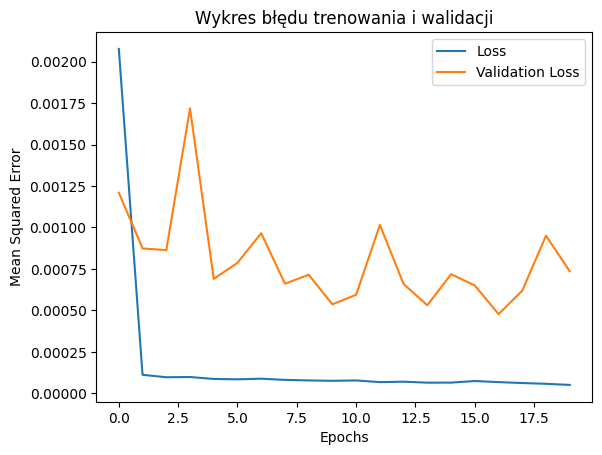

In [16]:
plt.plot(history.history['loss'], label='Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.title('Wykres błędu trenowania i walidacji')
plt.show()

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


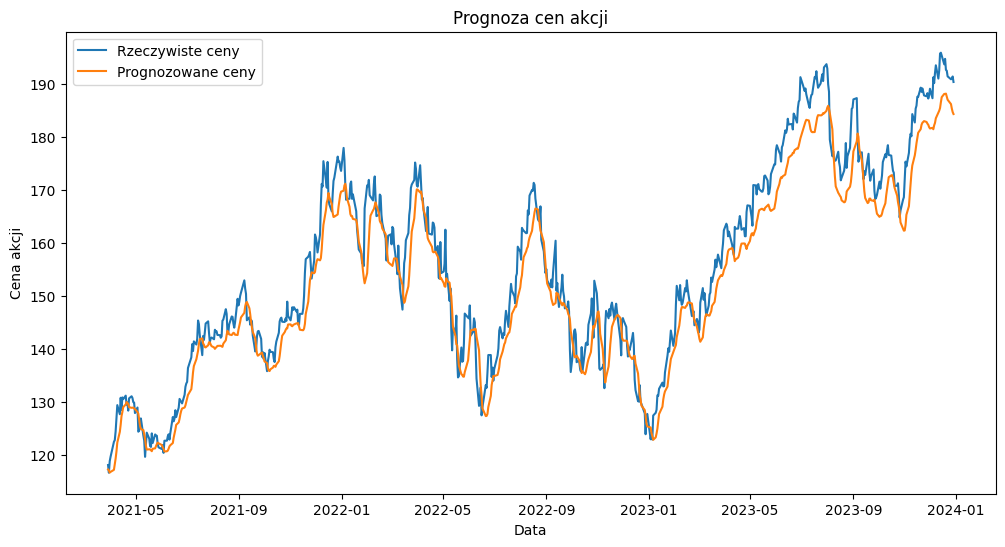

In [17]:
# Prognoza
predicted_prices = model.predict(X_test)
# Odwrócenie skalowania
y_test_rescaled = scaler.inverse_transform(y_test.reshape(-1, 1))
predicted_prices_rescaled = scaler.inverse_transform(predicted_prices)
# Wizualizacja wyników
plt.figure(figsize=(12, 6))
plt.plot(prices.index[-len(y_test):], y_test_rescaled, label='Rzeczywiste ceny')
plt.plot(prices.index[-len(y_test):], predicted_prices_rescaled, label='Prognozowane ceny')
plt.legend()
plt.title('Prognoza cen akcji')
plt.xlabel('Data')
plt.ylabel('Cena akcji')
plt.show()